# Figure 5 Generative Model Grid Search

Cache-first notebook for fitting the HD-MEA differentiation simulation to empirical active-site structure. The primary diagnostic is a **2D spatial KS statistic** between the empirical selected-electrode layout imprint and the simulated survivor layout imprint. Lower KS values indicate a better match.

Two model families are screened:

- **Axonal-only:** near-field exponential + axonal exponential. Grid axes: near-field relative amplitude and axonal decay length.
- **Ephaptic-axonal:** near-field exponential + gamma-modulated ephaptic interference term. Grid axes: near-field relative amplitude and interference frequency.

The notebook stores only derived result rows and figure summaries under `outputs/figure5_generative_model_grid_search/`. It does not store simulated coordinate clouds or empirical input tables in the figure cache. Synchrony is not used here; this figure fits the spatial active-electrode imprint only.

In [546]:
from dataclasses import asdict, replace
import hashlib
import json
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax.modeling import HDMEADifferentiationConfig, build_kernel_curves, make_hd_mea_grid, run_apoptosis_simulation
from ephax.plotting import PAPER_COLORS, apply_paper_style, compose_figure, export_figure, figure, group, panel

apply_paper_style()

{'font.family': ['DejaVu Sans'],
 'font.size': 5.5,
 'axes.titlesize': 6,
 'axes.labelsize': 5.5,
 'xtick.labelsize': 5.0,
 'ytick.labelsize': 5.0,
 'legend.fontsize': 5.0,
 'axes.labelpad': 1.0,
 'axes.titlepad': 2.0,
 'axes.linewidth': 0.4,
 'xtick.major.width': 0.4,
 'ytick.major.width': 0.4,
 'xtick.minor.width': 0.4,
 'ytick.minor.width': 0.4,
 'xtick.major.size': 1.2,
 'ytick.major.size': 1.2,
 'xtick.minor.size': 0.8,
 'ytick.minor.size': 0.8,
 'xtick.major.pad': 0.5,
 'ytick.major.pad': 0.5,
 'xtick.minor.pad': 0.5,
 'ytick.minor.pad': 0.5,
 'lines.linewidth': 0.4,
 'axes.grid': False,
 'figure.dpi': 160,
 'pdf.fonttype': 42,
 'ps.fonttype': 42,
 'svg.fonttype': 'none',
 'savefig.dpi': 450,
 'axes.prop_cycle': cycler('color', ['#40bfff', '#807fff', '#2ca02c', '#1f77b4', '#8c8c8c', '#E69F00', '#56B4E9', '#000000'])}

## Configuration

In [547]:
DATASET = "stim_removal_null"
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = [12, 14, 21, 22, 23, 26]
TARGET_DIV = max(AGGREGATE_DIVS)
EMPIRICAL_TOP_N = 100

# Use a physically matched downsampled lattice for fast grid search. Set to "confirm" for 220 x 120.
GRID_SEARCH_PROFILE = "screen"  # "screen" or "confirm"
GRID_SEARCH_FORCE_RECOMPUTE = False
GRID_SEARCH_RUN = True
GRID_REPLICATES = 10
RANDOM_SEED = 0

# Shared simulation settings.
SIMULATION_PLATING_LOSS_FRACTION = 0.70
SIMULATION_TARGET_FRACTION = 0.40
SIMULATION_SUBSAMPLE_SIZE = 20
NEAR_FIELD_DECAY_UM = 100.0
LAMBDA_EPH_UM = 1_000_000.0
V_EPH_M_S = 0.0833
V_AX_M_S = 0.60

# Grid axes. Keep these modest for first-pass screens; increase for confirmatory reruns.
NEAR_FIELD_RELATIVE_AMPLITUDE_GRID = np.array([um for um in np.logspace(0, 2, 21)])
AXONAL_DECAY_GRID_UM = np.array([um for um in np.logspace(2, 4, 41)])
EPHAPTIC_FREQUENCY_GRID_HZ = np.array([hz for hz in np.linspace(30.0, 70.0, 51)])

OUTPUT_DIR = repo_root / "outputs" / "figure5_generative_model_grid_search"
TABLE_DIR = OUTPUT_DIR / "tables"
SAVE_FIGURE = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

## Helpers

In [548]:
def profile_grid_config(profile: str):
    if profile == "screen":
        return 110, 60, 35.0
    if profile == "confirm":
        return 220, 120, 17.5
    raise ValueError(f"Unknown GRID_SEARCH_PROFILE={profile!r}")


def base_simulation_config(**overrides):
    cols, rows, pitch = profile_grid_config(GRID_SEARCH_PROFILE)
    cfg = HDMEADifferentiationConfig(
        grid_columns=cols,
        grid_rows=rows,
        pitch_um=pitch,
        # The base frequency is inert for axonal-only candidates and overridden for ephaptic-axonal candidates.
        hz=float(HDMEADifferentiationConfig().hz),
        v_eph_m_s=float(V_EPH_M_S),
        v_ax_m_s=float(V_AX_M_S),
        lambda_eph_um=float(LAMBDA_EPH_UM),
        # This base value is overridden for axonal-only candidates; ephaptic-axonal candidates do not use axonal_decay_um.
        axonal_decay_um=float(HDMEADifferentiationConfig().axonal_decay_um),
        near_field_decay_um=float(NEAR_FIELD_DECAY_UM),
        near_field_relative_amplitude=3.0,
        subsample_size=int(SIMULATION_SUBSAMPLE_SIZE),
        random_seed=int(RANDOM_SEED),
        plating_loss_fraction=float(SIMULATION_PLATING_LOSS_FRACTION),
        target_fraction=float(SIMULATION_TARGET_FRACTION),
        milestone_step_fraction=0.20,
    )
    return replace(cfg, **overrides)


def config_digest():
    payload = {
        "dataset": DATASET,
        "wells": list(map(int, AGGREGATE_WELLS)),
        "divs": list(map(int, AGGREGATE_DIVS)),
        "target_div": int(TARGET_DIV),
        "empirical_top_n": int(EMPIRICAL_TOP_N),
        "profile": GRID_SEARCH_PROFILE,
        "replicates": int(GRID_REPLICATES),
        "random_seed": int(RANDOM_SEED),
        "base_config": asdict(base_simulation_config()),
        "near_grid": np.asarray(NEAR_FIELD_RELATIVE_AMPLITUDE_GRID, float).round(8).tolist(),
        "axonal_decay_grid_um": np.asarray(AXONAL_DECAY_GRID_UM, float).round(8).tolist(),
        "ephaptic_frequency_grid_hz": np.asarray(EPHAPTIC_FREQUENCY_GRID_HZ, float).round(8).tolist(),
    }
    return hashlib.sha1(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:12]

CONFIG_DIGEST = config_digest()
GRID_RESULT_PATH = TABLE_DIR / f"grid_search_results_{CONFIG_DIGEST}.csv"
GRID_SUMMARY_PATH = TABLE_DIR / f"grid_search_summary_{CONFIG_DIGEST}.csv"
METHODS_PATH = TABLE_DIR / f"figure5_methods_{CONFIG_DIGEST}.csv"
RESULTS_PATH = TABLE_DIR / f"figure5_results_{CONFIG_DIGEST}.csv"

In [549]:
def load_selected_electrode_targets():
    path = repo_root / "outputs" / "figure4_activity_distance" / "tables" / "selected_electrode_coords.csv.gz"
    if not path.exists():
        raise FileNotFoundError(
            "Missing selected-electrode coordinate table from Figure 4. "
            "Run the Figure 4 selected-electrode table build once, or point this notebook to an equivalent table."
        )
    df = pd.read_csv(path)
    required = {"dataset", "well", "div", "recording_id", "electrode", "selected_rank", "x_um", "y_um"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Selected-electrode table is missing columns: {sorted(missing)}")
    df = df.loc[df["dataset"].astype(str) == DATASET].copy()
    df = df.loc[df["well"].astype(int).isin([int(w) for w in AGGREGATE_WELLS])].copy()
    available_divs = sorted(df["div"].astype(int).unique().tolist())
    if int(TARGET_DIV) not in available_divs:
        resolved = max(available_divs)
        print(f"TARGET_DIV={TARGET_DIV} not present in selected-electrode table; using latest available DIV {resolved}.")
    else:
        resolved = int(TARGET_DIV)
    target = df.loc[df["div"].astype(int) == resolved].copy()
    target = target.loc[pd.to_numeric(target["selected_rank"], errors="coerce") <= int(EMPIRICAL_TOP_N)].copy()
    if target.empty:
        raise ValueError("No empirical selected electrodes remain after TARGET_DIV / EMPIRICAL_TOP_N filtering.")
    target["resolved_target_div"] = resolved
    return target


def occupancy_grid_from_coords(coords_um: np.ndarray, config: HDMEADifferentiationConfig):
    coords = np.asarray(coords_um, dtype=float)
    counts = np.zeros((int(config.grid_rows), int(config.grid_columns)), dtype=float)
    if coords.size == 0:
        return counts
    col = np.rint(coords[:, 0] / float(config.pitch_um)).astype(int)
    row = np.rint(coords[:, 1] / float(config.pitch_um)).astype(int)
    keep = (row >= 0) & (row < config.grid_rows) & (col >= 0) & (col < config.grid_columns)
    np.add.at(counts, (row[keep], col[keep]), 1.0)
    return counts


def spatial_ks_2d_from_counts(observed_counts: np.ndarray, simulated_counts: np.ndarray):
    observed = np.asarray(observed_counts, dtype=float)
    simulated = np.asarray(simulated_counts, dtype=float)
    if observed.shape != simulated.shape:
        raise ValueError(f"Occupancy grids must have identical shape, got {observed.shape} and {simulated.shape}")
    obs_total = float(np.nansum(observed))
    sim_total = float(np.nansum(simulated))
    if obs_total <= 0 or sim_total <= 0:
        return np.nan
    obs_cdf = np.cumsum(np.cumsum(observed / obs_total, axis=0), axis=1)
    sim_cdf = np.cumsum(np.cumsum(simulated / sim_total, axis=0), axis=1)
    return float(np.nanmax(np.abs(obs_cdf - sim_cdf)))


def empirical_occupancy_grid(target_df: pd.DataFrame, config: HDMEADifferentiationConfig):
    return occupancy_grid_from_coords(target_df[["x_um", "y_um"]].to_numpy(float), config)

base_grid_config = base_simulation_config()
selected_target_df = load_selected_electrode_targets()
empirical_occupancy = empirical_occupancy_grid(selected_target_df, base_grid_config)
resolved_target_div = int(selected_target_df["resolved_target_div"].iloc[0])
print(
    f"Empirical target: DIV {resolved_target_div}, "
    f"{selected_target_df['recording_id'].nunique()} recordings, "
    f"{len(selected_target_df)} selected electrodes."
)

Empirical target: DIV 26, 6 recordings, 600 selected electrodes.


## Grid Search

In [550]:
def run_one_candidate(model: str, near_amp: float, axonal_decay_um, hz, replicate: int, target_occupancy: np.ndarray):
    cfg = base_simulation_config(
        near_field_relative_amplitude=float(near_amp),
        axonal_decay_um=float(axonal_decay_um if axonal_decay_um is not None else HDMEADifferentiationConfig().axonal_decay_um),
        hz=float(hz if hz is not None else HDMEADifferentiationConfig().hz),
        random_seed=int(RANDOM_SEED) + 10_000 * int(replicate) + (0 if model == "axonal_only" else 1_000),
    )
    grid = make_hd_mea_grid(cfg)
    result = run_apoptosis_simulation(
        grid,
        cfg,
        model_name=model,
        include_correlation=(model == "ephaptic_axonal"),
        show_progress=False,
    )
    sim_occupancy = occupancy_grid_from_coords(result["final_active"][["x_um", "y_um"]].to_numpy(float), cfg)
    ks_statistic = spatial_ks_2d_from_counts(target_occupancy, sim_occupancy)
    return {
        "model": model,
        "near_field_relative_amplitude": float(near_amp),
        "axonal_decay_um": np.nan if axonal_decay_um is None else float(axonal_decay_um),
        "hz": np.nan if hz is None else float(hz),
        "replicate": int(replicate),
        "ks_statistic": float(ks_statistic),
        "ks_pvalue": np.nan,
        "ks_kind": "2d_spatial_occupancy_cdf",
        "n_empirical_active_electrodes": int(np.nansum(target_occupancy)),
        "n_simulated_active_nodes": int(len(result["final_active"])),
        "final_active_nodes": int(len(result["final_active"])),
        "grid_columns": int(cfg.grid_columns),
        "grid_rows": int(cfg.grid_rows),
        "pitch_um": float(cfg.pitch_um),
        "target_div": int(resolved_target_div),
    }


def run_grid_search():
    rows = []
    started = time.time()
    for rep in range(int(GRID_REPLICATES)):
        for near_amp in NEAR_FIELD_RELATIVE_AMPLITUDE_GRID:
            for decay in AXONAL_DECAY_GRID_UM:
                rows.append(run_one_candidate("axonal_only", near_amp, decay, None, rep, empirical_occupancy))
            for hz in EPHAPTIC_FREQUENCY_GRID_HZ:
                rows.append(run_one_candidate("ephaptic_axonal", near_amp, None, hz, rep, empirical_occupancy))
        print(f"replicate {rep + 1}/{GRID_REPLICATES} complete after {(time.time() - started) / 60:.1f} min")
    return pd.DataFrame(rows)


def summarize_grid_results(results: pd.DataFrame):
    key_cols = ["model", "near_field_relative_amplitude", "axonal_decay_um", "hz", "target_div", "grid_columns", "grid_rows", "pitch_um", "ks_kind"]
    summary = (
        results.groupby(key_cols, dropna=False, as_index=False)
        .agg(
            ks_statistic_mean=("ks_statistic", "mean"),
            ks_statistic_median=("ks_statistic", "median"),
            ks_statistic_std=("ks_statistic", "std"),
            ks_pvalue_median=("ks_pvalue", "median"),
            n_replicates=("replicate", "nunique"),
            final_active_nodes=("final_active_nodes", "median"),
        )
    )
    return summary

if GRID_RESULT_PATH.exists() and GRID_SUMMARY_PATH.exists() and not GRID_SEARCH_FORCE_RECOMPUTE:
    grid_results = pd.read_csv(GRID_RESULT_PATH)
    grid_summary = pd.read_csv(GRID_SUMMARY_PATH)
    print(f"Loaded cached grid-search result rows from {GRID_RESULT_PATH}")
elif GRID_SEARCH_RUN:
    grid_results = run_grid_search()
    grid_summary = summarize_grid_results(grid_results)
    grid_results.to_csv(GRID_RESULT_PATH, index=False)
    grid_summary.to_csv(GRID_SUMMARY_PATH, index=False)
    print(f"Wrote grid-search summaries to {TABLE_DIR}")
else:
    grid_results = pd.DataFrame()
    grid_summary = pd.DataFrame()
    print("GRID_SEARCH_RUN=False and no compatible cache was loaded.")

grid_summary.head()

replicate 1/10 complete after 0.7 min
replicate 2/10 complete after 1.5 min
replicate 3/10 complete after 2.2 min
replicate 4/10 complete after 2.9 min
replicate 5/10 complete after 3.7 min
replicate 6/10 complete after 4.4 min
replicate 7/10 complete after 5.1 min
replicate 8/10 complete after 5.9 min
replicate 9/10 complete after 6.6 min
replicate 10/10 complete after 7.3 min
Wrote grid-search summaries to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure5_generative_model_grid_search/tables


,model,near_field_relative_amplitude,axonal_decay_um,hz,target_div,grid_columns,grid_rows,pitch_um,ks_kind,ks_statistic_mean,ks_statistic_median,ks_statistic_std,ks_pvalue_median,n_replicates,final_active_nodes
0,axonal_only,1.0,100.000000,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.268055,0.266470,0.013616,NaN,10,792.0
1,axonal_only,1.0,112.201845,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.269273,0.273664,0.013794,NaN,10,792.0
2,axonal_only,1.0,125.892541,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.268844,0.267893,0.011008,NaN,10,792.0
3,axonal_only,1.0,141.253754,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.270995,0.272943,0.021196,NaN,10,792.0
4,axonal_only,1.0,158.489319,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.270470,0.268910,0.011635,NaN,10,792.0


In [551]:
def best_rows(summary: pd.DataFrame):
    if summary.empty:
        return pd.DataFrame()
    pieces = []
    for model, sub in summary.groupby("model", sort=True):
        idx = pd.to_numeric(sub["ks_statistic_mean"], errors="coerce").idxmin()
        pieces.append(sub.loc[[idx]].copy())
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()

best_grid_rows = best_rows(grid_summary)
best_grid_rows

,model,near_field_relative_amplitude,axonal_decay_um,hz,target_div,grid_columns,grid_rows,pitch_um,ks_kind,ks_statistic_mean,ks_statistic_median,ks_statistic_std,ks_pvalue_median,n_replicates,final_active_nodes
0,axonal_only,3.981072,112.201845,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.260904,0.264394,0.018100,NaN,10,792.0
1,ephaptic_axonal,15.848932,NaN,34.8,26,110,60,35.0,2d_spatial_occupancy_cdf,0.175868,0.178976,0.013989,NaN,10,792.0


## Best-Fit Layout Imprints

For visualization only, rerun the best candidate from each model family once and place the simulated survivor layout next to the empirical active-electrode target. This does not change the grid-search cache; it only exposes the spatial imprint behind the best KS scores.

In [552]:
def matching_grid_result_rows(best_row: pd.Series):
    model = str(best_row["model"])
    rows = grid_results.loc[grid_results["model"] == model].copy()
    rows = rows.loc[np.isclose(rows["near_field_relative_amplitude"].astype(float), float(best_row["near_field_relative_amplitude"]))]
    if model == "axonal_only":
        rows = rows.loc[np.isclose(rows["axonal_decay_um"].astype(float), float(best_row["axonal_decay_um"]))]
    else:
        rows = rows.loc[np.isclose(rows["hz"].astype(float), float(best_row["hz"]))]
    return rows


def representative_grid_result_row(best_row: pd.Series):
    rows = matching_grid_result_rows(best_row)
    if rows.empty:
        return None
    target = float(best_row["ks_statistic_mean"])
    idx = (rows["ks_statistic"].astype(float) - target).abs().idxmin()
    return rows.loc[idx]


def run_best_layout_candidate(row: pd.Series):
    model = str(row["model"])
    representative = representative_grid_result_row(row)
    replicate = 0 if representative is None else int(representative["replicate"])
    cfg = base_simulation_config(
        near_field_relative_amplitude=float(row["near_field_relative_amplitude"]),
        axonal_decay_um=float(row["axonal_decay_um"]) if model == "axonal_only" else HDMEADifferentiationConfig().axonal_decay_um,
        hz=float(row["hz"]) if model == "ephaptic_axonal" else HDMEADifferentiationConfig().hz,
        random_seed=int(RANDOM_SEED) + 10_000 * int(replicate) + (0 if model == "axonal_only" else 1_000),
    )
    grid = make_hd_mea_grid(cfg)
    result = run_apoptosis_simulation(
        grid,
        cfg,
        model_name=f"best_{model}",
        include_correlation=(model == "ephaptic_axonal"),
        show_progress=False,
    )
    coords = result["final_active"][["x_um", "y_um"]].to_numpy(float)
    occupancy = occupancy_grid_from_coords(coords, cfg)
    layout_ks = spatial_ks_2d_from_counts(empirical_occupancy, occupancy)
    return {
        "model": model,
        "config": cfg,
        "coords_um": coords,
        "occupancy": occupancy,
        "ks_statistic": float(row["ks_statistic_mean"]),
        "layout_ks_statistic": float(layout_ks),
        "representative_replicate": int(replicate),
        "representative_replicate_ks": np.nan if representative is None else float(representative["ks_statistic"]),
        "row": row.to_dict(),
    }


def build_best_layout_data(best: pd.DataFrame):
    data = {
        "empirical": {
            "model": "empirical",
            "coords_um": selected_target_df[["x_um", "y_um"]].to_numpy(float),
            "occupancy": empirical_occupancy,
            "ks_statistic": 0.0,
            "config": base_grid_config,
        }
    }
    if best.empty:
        return data
    for _, row in best.iterrows():
        data[str(row["model"])] = run_best_layout_candidate(row)
    return data

best_layout_data = build_best_layout_data(best_grid_rows)
list(best_layout_data)

['empirical', 'axonal_only', 'ephaptic_axonal']

## Figure Panels

In [553]:
def grid_ks_color_limits(summary: pd.DataFrame):
    if summary.empty or "ks_statistic_mean" not in summary:
        return None, None
    values = pd.to_numeric(summary["ks_statistic_mean"], errors="coerce").to_numpy(float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None, None
    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))
    if np.isclose(vmin, vmax):
        pad = max(1e-6, 0.05 * abs(vmin))
        vmin -= pad
        vmax += pad
    return vmin, vmax

SAMPLE_MARKERS = ("o", "^", "s")


def model_color(model: str):
    return PAPER_COLORS.get("axonal_only" if model == "axonal_only" else "ephaptic_axonal", "0.2")


def model_x_column(model: str):
    return "axonal_decay_um" if model == "axonal_only" else "hz"


def row_grid_xy(row: pd.Series, model: str):
    return float(row[model_x_column(model)]), float(row["near_field_relative_amplitude"])


def draw_sample_marker(ax, model: str, marker_idx: int, *, xy_axes=(0.05, 0.84), size=45, clip_on=False):
    marker = SAMPLE_MARKERS[int(marker_idx) % len(SAMPLE_MARKERS)]
    ax.scatter(
        [xy_axes[0]],
        [xy_axes[1]],
        transform=ax.transAxes,
        marker=marker,
        s=size,
        facecolor=model_color(model),
        edgecolor="black",
        linewidth=0.45,
        zorder=20,
        clip_on=clip_on,
    )


def _add_nonlayout_text(ax, *args, **kwargs):
    text = ax.text(*args, **kwargs)
    text.set_in_layout(False)
    return text


def add_manual_axis_cues(ax, *, x_label, y_label, x_ticks, y_ticks):
    # These labels are visual annotations only; real ticks/labels would change the
    # constrained layout and make the first example narrower than the others.
    for xpos, label in x_ticks:
        _add_nonlayout_text(
            ax, xpos, -0.105, label, transform=ax.transAxes, ha="center", va="top", fontsize=6, clip_on=False
        )
        ax.plot([xpos, xpos], [0.0, -0.035], transform=ax.transAxes, color="black", lw=0.45, clip_on=False)
    for ypos, label in y_ticks:
        _add_nonlayout_text(
            ax, -0.07, ypos, label, transform=ax.transAxes, ha="right", va="center", fontsize=6, clip_on=False
        )
        ax.plot([0.0, -0.025], [ypos, ypos], transform=ax.transAxes, color="black", lw=0.45, clip_on=False)
    _add_nonlayout_text(
        ax, 0.5, -0.25, x_label, transform=ax.transAxes, ha="center", va="top", fontsize=6, clip_on=False
    )
    _add_nonlayout_text(
        ax, -0.22, 0.5, y_label, transform=ax.transAxes, ha="right", va="center", rotation=90, fontsize=6, clip_on=False
    )


def compact_tick_label(value):
    value = float(value)
    if abs(value) >= 1000 or (0 < abs(value) < 0.01):
        return f"{value:.1g}"
    return f"{value:.2g}"


def draw_grid_heatmap(ax, summary: pd.DataFrame, *, model: str, vmin=None, vmax=None, sample_rows=None):
    if summary.empty:
        ax.text(0.5, 0.5, "No grid-search cache", ha="center", va="center", transform=ax.transAxes)
        return None
    sub = summary.loc[summary["model"] == model].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f"No {model} rows", ha="center", va="center", transform=ax.transAxes)
        return None
    x_col = model_x_column(model)
    pivot = sub.pivot_table(
        index="near_field_relative_amplitude",
        columns=x_col,
        values="ks_statistic_mean",
        aggfunc="mean",
    ).sort_index().sort_index(axis=1)
    x = pivot.columns.to_numpy(float)
    y = pivot.index.to_numpy(float)
    z = pivot.to_numpy(float)
    if vmin is None or vmax is None:
        vmin, vmax = grid_ks_color_limits(summary)
    mesh = ax.pcolormesh(x, y, z, shading="nearest", cmap="magma_r", vmin=vmin, vmax=vmax)
    best_idx = np.unravel_index(np.nanargmin(z), z.shape)
    ax.scatter(
        [x[best_idx[1]]],
        [y[best_idx[0]]],
        marker="*",
        s=150,
        facecolor=model_color(model),
        edgecolor="black",
        linewidth=0.55,
        zorder=7,
    )
    rows_to_mark = sample_rows_for_model(model, n_samples=3) if sample_rows is None else list(sample_rows)
    for marker_idx, marker_row in enumerate(rows_to_mark[:3]):
        mx, my = row_grid_xy(marker_row, model)
        ax.scatter(
            [mx],
            [my],
            marker=SAMPLE_MARKERS[marker_idx % len(SAMPLE_MARKERS)],
            s=45,
            facecolor=model_color(model),
            edgecolor="black",
            linewidth=0.45,
            zorder=6,
        )
    best_value = z[best_idx]
    ax.text(
        0.03,
        0.97,
        f"best KS={best_value:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none", "pad": 2},
    )
    ax.set_ylabel("near-field relative amplitude")
    ax.set_yscale("log")
    if model == "axonal_only":
        ax.set_xlabel("axonal decay length (um)")
        ax.set_title("Axonal-only grid search")
        ax.set_xscale("log")
    else:
        ax.set_xlabel("interference frequency (Hz)")
        ax.set_title("Ephaptic-axonal grid search")
    return mesh


def draw_best_parameter_table(ax, best: pd.DataFrame):
    ax.axis("off")
    if best.empty:
        ax.text(0.0, 1.0, "No best-fit rows", va="top")
        return
    lines = [
        f"Target: DIV {resolved_target_div}, top {EMPIRICAL_TOP_N} active electrodes",
        f"Empirical recordings: {selected_target_df['recording_id'].nunique()}",
        f"Grid profile: {GRID_SEARCH_PROFILE}",
        "",
    ]
    for _, row in best.iterrows():
        if row["model"] == "axonal_only":
            param = f"decay={row['axonal_decay_um']:.0f} um"
        else:
            param = f"f={row['hz']:.1f} Hz"
        lines.append(
            f"{row['model']}: KS={row['ks_statistic_mean']:.3f}, "
            f"near={row['near_field_relative_amplitude']:.2f}, {param}"
        )
    ax.text(0.0, 1.0, "\n".join(lines), va="top", ha="left")


def draw_axonal_panel(data, ax, **options):
    vmin, vmax = grid_ks_color_limits(grid_summary)
    mesh = draw_grid_heatmap(ax, grid_summary, model="axonal_only", vmin=vmin, vmax=vmax, sample_rows=sample_rows_for_model("axonal_only", n_samples=3))
    return {"mappable": mesh, "colorbar_label": "KS statistic"} if mesh is not None else None


def draw_ephaptic_panel(data, ax, **options):
    vmin, vmax = grid_ks_color_limits(grid_summary)
    mesh = draw_grid_heatmap(ax, grid_summary, model="ephaptic_axonal", vmin=vmin, vmax=vmax, sample_rows=sample_rows_for_model("ephaptic_axonal", n_samples=3))
    return {"mappable": mesh, "colorbar_label": "KS statistic"} if mesh is not None else None



def layout_comparison_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, 3, wspace=0.18)
    return [fig.add_subplot(gs[0, i]) for i in range(3)]


def draw_layout_imprint(ax, coords_um: np.ndarray, title: str, color: str, *, ks_text=None):
    cfg = base_grid_config
    width_um = (int(cfg.grid_columns) - 1) * float(cfg.pitch_um)
    height_um = (int(cfg.grid_rows) - 1) * float(cfg.pitch_um)
    ax.set_facecolor("black")
    coords = np.asarray(coords_um, dtype=float)
    if coords.size:
        ax.scatter(coords[:, 0], coords[:, 1], s=4.5, c=color, alpha=0.75, linewidths=0)
    ax.set_xlim(0, width_um)
    ax.set_ylim(0, height_um)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    if ks_text is not None:
        ax.text(
            0.98,
            0.04,
            ks_text,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            color="white",
            bbox={"facecolor": "black", "alpha": 0.55, "edgecolor": "none", "pad": 1.5},
        )


def draw_layout_comparison_panel(data, axes, **options):
    if not isinstance(axes, (list, tuple)) or len(axes) != 3:
        raise ValueError("draw_layout_comparison_panel expects three axes")
    layout_data = best_layout_data if data is None else data
    draw_layout_imprint(
        axes[0],
        layout_data["empirical"]["coords_um"],
        f"Empirical target\nDIV {resolved_target_div}, top {EMPIRICAL_TOP_N}",
        PAPER_COLORS.get("highlight", "#E69F00"),
        ks_text="target",
    )
    if "axonal_only" in layout_data:
        draw_layout_imprint(
            axes[1],
            layout_data["axonal_only"]["coords_um"],
            "Best axonal-only",
            PAPER_COLORS.get("axonal_only", "#40bfff"),
            ks_text=f"KS={layout_data['axonal_only']['ks_statistic']:.3f}",
        )
    else:
        axes[1].text(0.5, 0.5, "No axonal-only fit", ha="center", va="center", transform=axes[1].transAxes)
    if "ephaptic_axonal" in layout_data:
        draw_layout_imprint(
            axes[2],
            layout_data["ephaptic_axonal"]["coords_um"],
            "Best ephaptic-axonal",
            PAPER_COLORS.get("ephaptic_axonal", "#807fff"),
            ks_text=f"KS={layout_data['ephaptic_axonal']['ks_statistic']:.3f}",
        )
    else:
        axes[2].text(0.5, 0.5, "No ephaptic-axonal fit", ha="center", va="center", transform=axes[2].transAxes)



def config_from_grid_row(row: pd.Series, *, replicate=None):
    model = str(row["model"])
    rep = 0 if replicate is None else int(replicate)
    return base_simulation_config(
        near_field_relative_amplitude=float(row["near_field_relative_amplitude"]),
        axonal_decay_um=float(row["axonal_decay_um"]) if model == "axonal_only" else HDMEADifferentiationConfig().axonal_decay_um,
        hz=float(row["hz"]) if model == "ephaptic_axonal" else HDMEADifferentiationConfig().hz,
        random_seed=int(RANDOM_SEED) + 10_000 * rep + (0 if model == "axonal_only" else 1_000),
    )


# Backward-compatible alias used by earlier diagnostic cells.
def config_from_best_row(row: pd.Series):
    return config_from_grid_row(row)


def best_row_for_model(model: str):
    rows = best_grid_rows.loc[best_grid_rows["model"] == model]
    return None if rows.empty else rows.iloc[0]


def sample_rows_for_model(model: str, n_samples: int = 3):
    if grid_summary.empty:
        return []
    sub = grid_summary.loc[grid_summary["model"] == model].copy()
    if sub.empty:
        return []
    x_col = model_x_column(model)
    sub[x_col] = pd.to_numeric(sub[x_col], errors="coerce")
    sub["near_field_relative_amplitude"] = pd.to_numeric(sub["near_field_relative_amplitude"], errors="coerce")
    sub["ks_statistic_mean"] = pd.to_numeric(sub["ks_statistic_mean"], errors="coerce")
    sub = sub.dropna(subset=[x_col, "near_field_relative_amplitude", "ks_statistic_mean"])
    if sub.empty:
        return []
    best_idx = sub["ks_statistic_mean"].idxmin()
    candidates = []
    x_vals = np.sort(sub[x_col].unique())
    y_vals = np.sort(sub["near_field_relative_amplitude"].unique())
    targets = [
        (x_vals[0], y_vals[0]),
        (x_vals[-1], y_vals[0]),
        (x_vals[len(x_vals) // 2], y_vals[-1]),
    ]
    used = {best_idx}
    for x_t, y_t in targets:
        if len(candidates) >= int(n_samples):
            break
        dist = np.abs(np.log(sub[x_col].to_numpy(float)) - np.log(float(x_t))) + np.abs(
            np.log(sub["near_field_relative_amplitude"].to_numpy(float)) - np.log(float(y_t))
        )
        for pos in np.argsort(dist):
            idx = sub.index[int(pos)]
            if idx not in used:
                candidates.append(sub.loc[idx])
                used.add(idx)
                break
    if len(candidates) < int(n_samples):
        for idx, row in sub.sort_values("ks_statistic_mean").iterrows():
            if len(candidates) >= int(n_samples):
                break
            if idx not in used:
                candidates.append(row)
                used.add(idx)
    return candidates[: int(n_samples)]


def representative_replicate_for_summary_row(row: pd.Series):
    match = matching_grid_result_rows(row)
    if match.empty:
        return 0
    target = float(row.get("ks_statistic_mean", np.nan))
    if np.isfinite(target):
        vals = pd.to_numeric(match["ks_statistic"], errors="coerce")
        idx = (vals - target).abs().idxmin()
        return int(match.loc[idx, "replicate"])
    return int(match.iloc[0]["replicate"])


def candidate_label(row: pd.Series):
    model = str(row["model"])
    if model == "axonal_only":
        return f"decay {float(row['axonal_decay_um']):.0f} um"
    return f"{float(row['hz']):.1f} Hz"


def draw_candidate_kernel(ax, row: pd.Series, *, show_legend: bool = False, show_axes: bool = False):
    model = str(row["model"])
    color = model_color(model)
    cfg = config_from_grid_row(row)
    grid = make_hd_mea_grid(cfg)
    curves = build_kernel_curves(grid, cfg, n_points=900)
    r = curves["r_um"]
    if model == "axonal_only":
        y_main = curves["axonal"]
        ax.plot(r, y_main, color=color, lw=1.0, label="near-field + axonal")
        ax.plot(r, curves["near_field"], color=color, lw=0.65, ls=":", alpha=0.8, label="near-field")
        ax.plot(r, curves["axonal_component"], color=color, lw=0.65, ls="--", alpha=0.8, label="axonal")
    else:
        y_main = curves["ephaptic_axonal"]
        ax.plot(r, y_main, color=color, lw=1.0, label="near-field + interference")
        ax.plot(r, curves["near_field"], color=color, lw=0.65, ls=":", alpha=0.8, label="near-field")
        ax.plot(r, curves["ephaptic"], color=color, lw=0.65, ls="--", alpha=0.85, label="interference")
    ax.axhline(0, color="0.6", lw=0.45)
    ax.set_xlim(0, 3850)
    finite_y = np.asarray(y_main, dtype=float)
    finite_y = finite_y[np.isfinite(finite_y)]
    if finite_y.size:
        lo, hi = float(np.nanmin(finite_y)), float(np.nanmax(finite_y))
        pad = 0.08 * max(hi - lo, 1e-9)
        ax.set_ylim(lo - pad, hi + pad)
    ax.set_box_aspect(2100 / 3850)
    ax.set_anchor("S")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(length=0, pad=0)
    if show_axes:
        lo, hi = ax.get_ylim()
        add_manual_axis_cues(
            ax,
            x_label="distance (um)",
            y_label="kernel",
            x_ticks=[(0.0, "0"), (1.0, "3850")],
            y_ticks=[(0.0, compact_tick_label(lo)), (1.0, compact_tick_label(hi))],
        )
    ax.set_title(f"{candidate_label(row)}\nKS={float(row['ks_statistic_mean']):.3f}", fontsize=7, pad=0.8)
    if show_legend:
        ax.legend(frameon=False, loc="upper right", fontsize=7)


def simulate_candidate_layout(row: pd.Series):
    rep = representative_replicate_for_summary_row(row)
    cfg = config_from_grid_row(row, replicate=rep)
    model = str(row["model"])
    grid = make_hd_mea_grid(cfg)
    result = run_apoptosis_simulation(
        grid,
        cfg,
        model_name=f"sample_{model}",
        include_correlation=(model == "ephaptic_axonal"),
        show_progress=False,
    )
    return result["final_active"][["x_um", "y_um"]].to_numpy(float)


def draw_candidate_projection(ax, row: pd.Series, *, show_axes: bool = False):
    model = str(row["model"])
    color = model_color(model)
    coords = simulate_candidate_layout(row)
    draw_layout_imprint(ax, coords, "", color, ks_text=None)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(length=0, pad=0)
    if show_axes:
        add_manual_axis_cues(
            ax,
            x_label="x (um)",
            y_label="y (um)",
            x_ticks=[(0.0, "0"), (1.0, "3850")],
            y_ticks=[(0.0, "0"), (1.0, "2100")],
        )
    ax.set_title("")
    ax.set_box_aspect(2100 / 3850)
    ax.set_anchor("N")


def model_sample_axes_factory(fig, subplotspec):
    outer = subplotspec.subgridspec(1, 3, wspace=0.0, hspace=0.0)
    axes = []
    for col in range(3):
        inner = outer[0, col].subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.07)
        axes.append((fig.add_subplot(inner[0, 0]), fig.add_subplot(inner[1, 0])))
    return axes


def draw_model_sample_panel(data, axes, **options):
    model = options.get("model", "axonal_only")
    rows = sample_rows_for_model(model, n_samples=3)
    axes = list(axes)
    for idx, pair in enumerate(axes):
        kernel_ax, layout_ax = pair
        if idx >= len(rows):
            kernel_ax.set_axis_off()
            layout_ax.set_axis_off()
            continue
        row = rows[idx]
        draw_candidate_kernel(kernel_ax, row, show_legend=False, show_axes=(idx == 0))
        draw_candidate_projection(layout_ax, row, show_axes=(idx == 0))
        draw_sample_marker(kernel_ax, model, idx, xy_axes=(0.055, 0.82), size=45)
        draw_sample_marker(layout_ax, model, idx, xy_axes=(0.055, 0.86), size=45)


def draw_single_best_kernel_panel(ax, model: str, *, show_legend: bool = False):
    row = best_row_for_model(model)
    if row is None:
        ax.text(0.5, 0.5, f"No {model} fit", ha="center", va="center", transform=ax.transAxes)
        return
    draw_candidate_kernel(ax, row, show_legend=show_legend, show_axes=True)
    ax.set_xticks([0, 1000, 2000, 3000])
    ax.set_xlabel("distance (um)")
    ax.set_title("Best axonal-only kernel" if model == "axonal_only" else "Best ephaptic-axonal kernel")


def draw_axonal_kernel_panel(data, ax, **options):
    draw_single_best_kernel_panel(ax, "axonal_only", show_legend=bool(options.get("show_legend", False)))


def draw_ephaptic_kernel_panel(data, ax, **options):
    draw_single_best_kernel_panel(ax, "ephaptic_axonal", show_legend=bool(options.get("show_legend", False)))

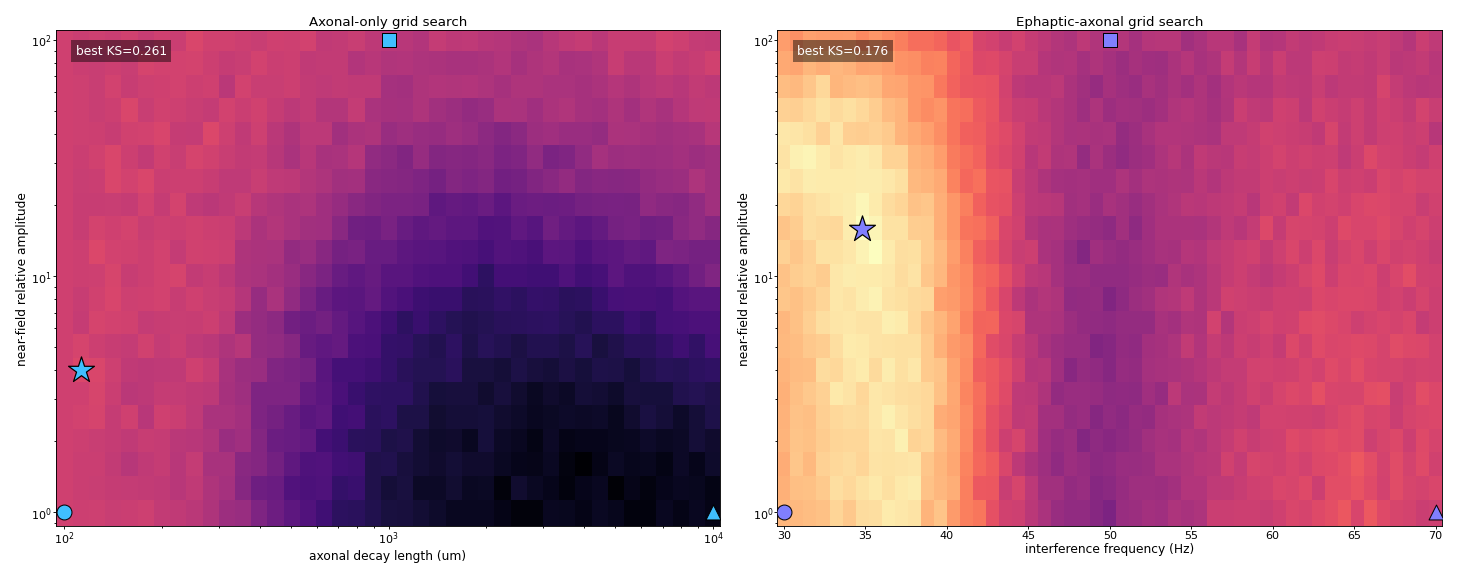

In [554]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), constrained_layout=True)
draw_grid_heatmap(axes[0], grid_summary, model="axonal_only")
draw_grid_heatmap(axes[1], grid_summary, model="ephaptic_axonal")
plt.show()

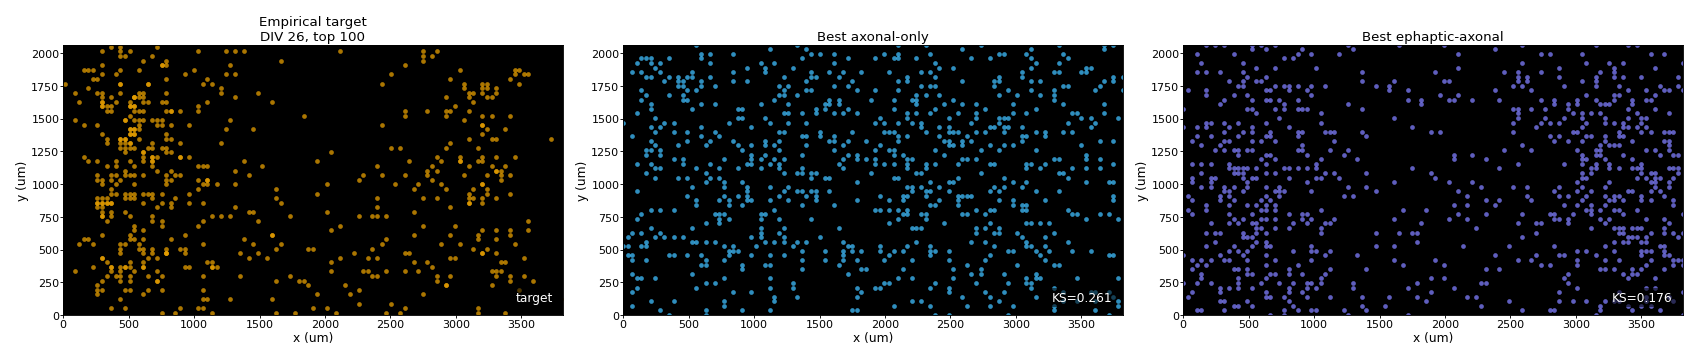

In [555]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.8), constrained_layout=True)
draw_layout_comparison_panel(best_layout_data, list(axes))
plt.show()

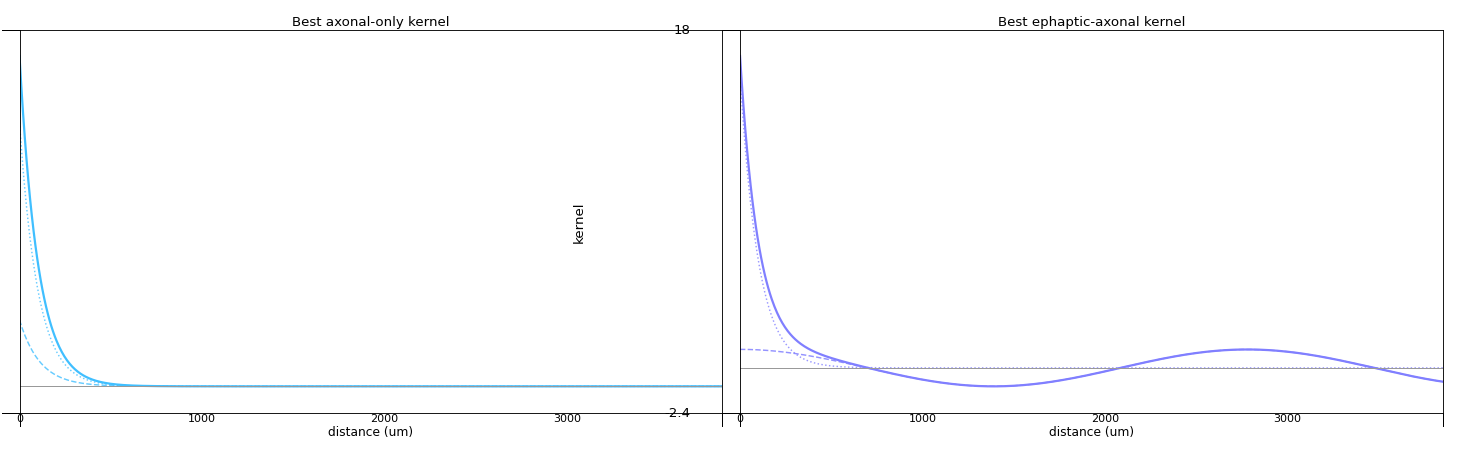

In [556]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0), constrained_layout=True)
draw_axonal_kernel_panel(None, axes[0])
draw_ephaptic_kernel_panel(None, axes[1])
plt.show()

## Composed Figure 5

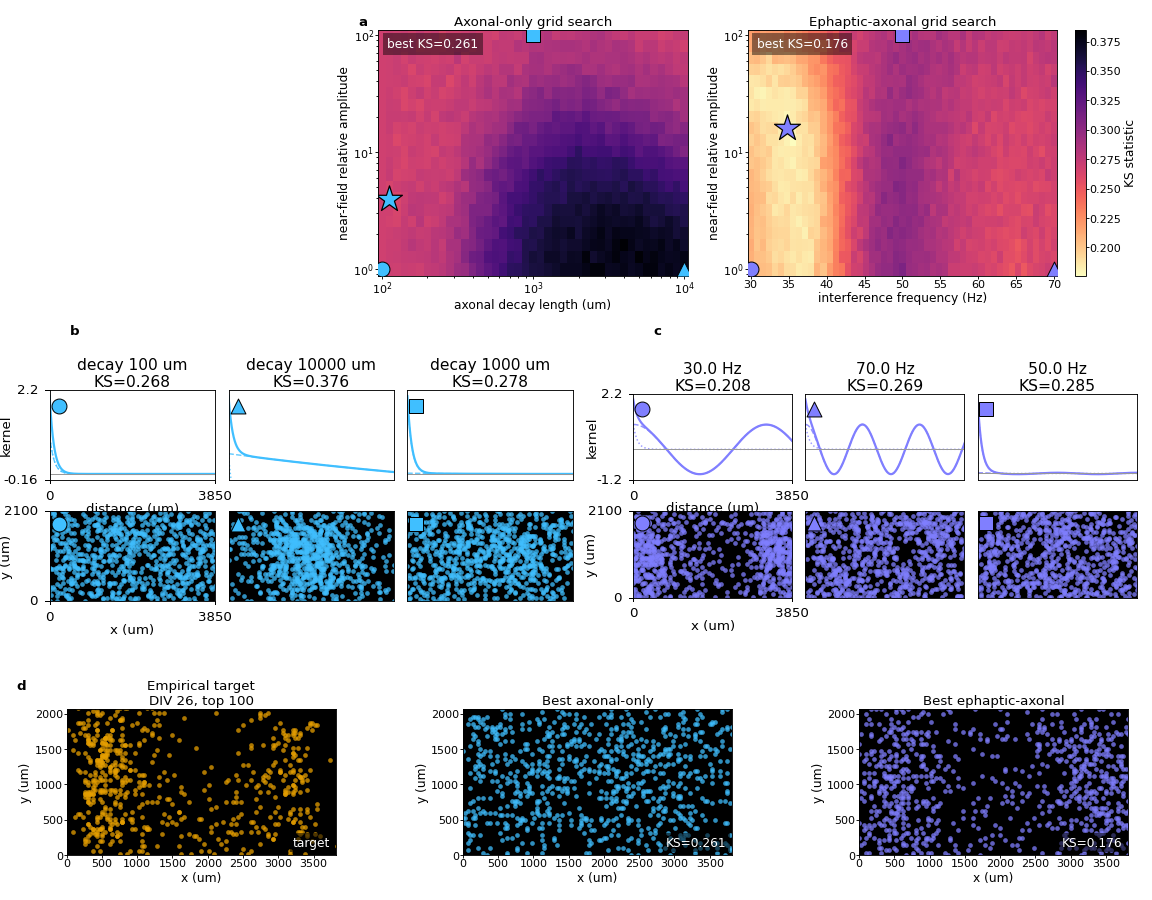

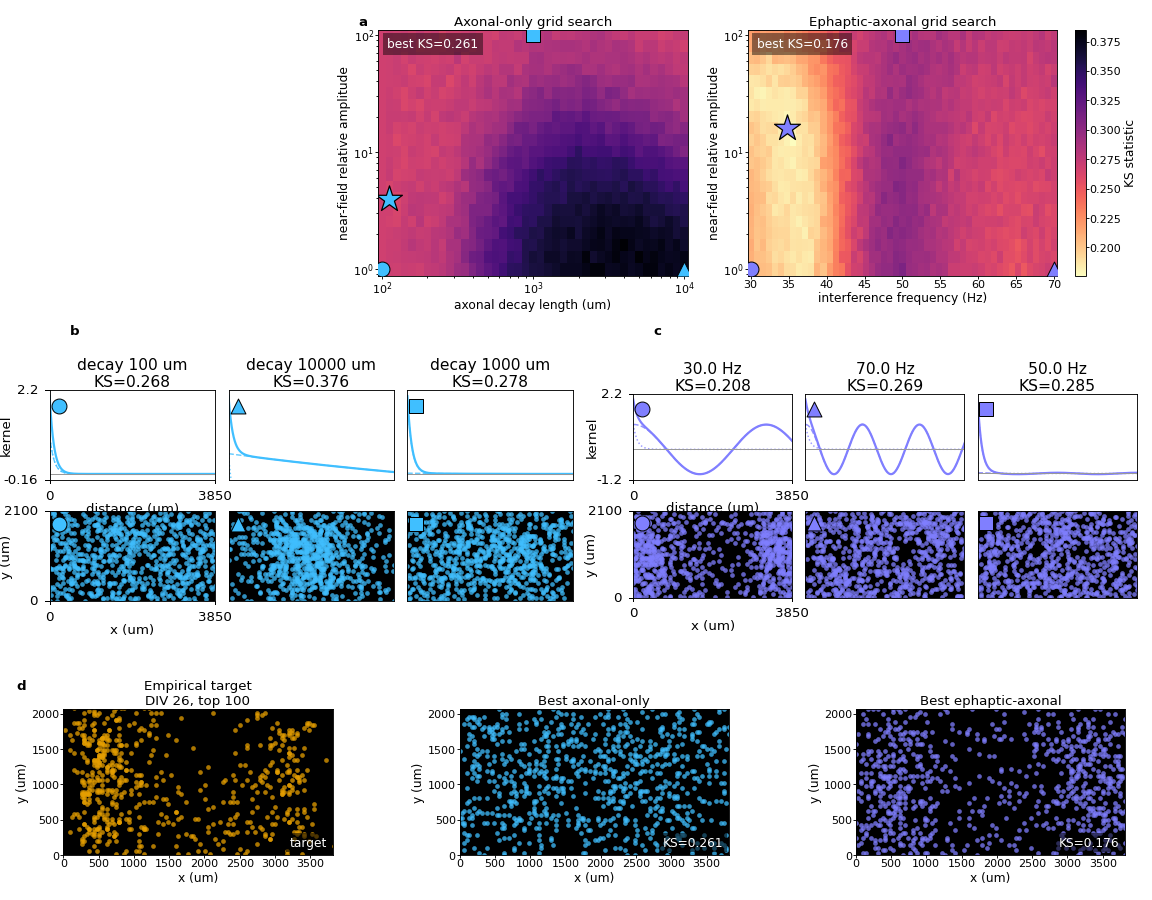

In [557]:
def draw_axonal_sample_panel(data, axes, **options):
    draw_model_sample_panel(data, axes, model="axonal_only")


def draw_ephaptic_sample_panel(data, axes, **options):
    draw_model_sample_panel(data, axes, model="ephaptic_axonal")


fig5 = compose_figure(
    figure(width="two_column", height=140, ncols=24, rows=[0.37, 0.43, 0.25]),
    [
        group(
            "a",
            label="a",
            loc=(0, 7, 1, 17),
            ncols=2,
            shared_colorbar=True,
            children=[
                panel("a_axonal", draw=draw_axonal_panel),
                panel("a_ephaptic", draw=draw_ephaptic_panel),
            ],
        ),
        panel(
            "b",
            label="b",
            loc=(1, 1, 1, 11),
            draw=draw_axonal_sample_panel,
            axes_factory=model_sample_axes_factory,
        ),
        panel(
            "c",
            label="c",
            loc=(1, 13, 1, 11),
            draw=draw_ephaptic_sample_panel,
            axes_factory=model_sample_axes_factory,
        ),
        panel(
            "d",
            label="d",
            loc=(2, 0, 1, 24),
            draw=draw_layout_comparison_panel,
            data=best_layout_data,
            axes_factory=layout_comparison_axes_factory,
        ),
    ],
)
fig5.fig


In [559]:
def write_report_tables():
    methods = pd.DataFrame([
        {"parameter": "DATASET", "value": DATASET, "note": "Empirical selected-electrode source dataset."},
        {"parameter": "TARGET_DIV", "value": resolved_target_div, "note": "DIV used as empirical target for KS fitting."},
        {"parameter": "EMPIRICAL_TOP_N", "value": EMPIRICAL_TOP_N, "note": "Top active electrodes per recording used for empirical pair-distance distribution."},
        {"parameter": "GRID_SEARCH_PROFILE", "value": GRID_SEARCH_PROFILE, "note": "screen uses a downsampled physical HD-MEA grid; confirm uses full density."},
        {"parameter": "SIMULATION_PLATING_LOSS_FRACTION", "value": SIMULATION_PLATING_LOSS_FRACTION, "note": "Randomly removed fraction before activity-dependent pruning."},
        {"parameter": "SIMULATION_TARGET_FRACTION", "value": SIMULATION_TARGET_FRACTION, "note": "Target survivor fraction after pruning."},
        {"parameter": "NEAR_FIELD_DECAY_UM", "value": NEAR_FIELD_DECAY_UM, "note": "Fixed decay length of immediate near-field term."},
        {"parameter": "GRID_REPLICATES", "value": GRID_REPLICATES, "note": "Independent simulation repeats per grid candidate."},
        {"parameter": "RANDOM_SEED", "value": RANDOM_SEED, "note": "Base random seed for grid-search replicates."},
        {"parameter": "SIMULATION_SUBSAMPLE_SIZE", "value": SIMULATION_SUBSAMPLE_SIZE, "note": "Number of candidate neighbours sampled per pruning update."},
        {"parameter": "V_EPH_M_S", "value": V_EPH_M_S, "note": "Ephaptic propagation speed used for the spatial wavelength calculation."},
        {"parameter": "V_AX_M_S", "value": V_AX_M_S, "note": "Axonal propagation speed used for the spatial wavelength calculation."},
        {"parameter": "LAMBDA_EPH_UM", "value": LAMBDA_EPH_UM, "note": "Ephaptic exponential length scale used by the model."},
    ])
    results = best_grid_rows.copy()
    methods.to_csv(METHODS_PATH, index=False)
    results.to_csv(RESULTS_PATH, index=False)
    return methods, results

figure5_methods, figure5_results = write_report_tables()
if SAVE_FIGURE:
    export_figure(fig5.fig, OUTPUT_DIR / "figure5_generative_model_grid_search", formats=("pdf", "svg", "png"))
    print(f"Saved Figure 5 draft and report tables to {OUTPUT_DIR}")
figure5_results

Saved Figure 5 draft and report tables to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure5_generative_model_grid_search


,model,near_field_relative_amplitude,axonal_decay_um,hz,target_div,grid_columns,grid_rows,pitch_um,ks_kind,ks_statistic_mean,ks_statistic_median,ks_statistic_std,ks_pvalue_median,n_replicates,final_active_nodes
0,axonal_only,3.981072,112.201845,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.260904,0.264394,0.018100,NaN,10,792.0
1,ephaptic_axonal,15.848932,NaN,34.8,26,110,60,35.0,2d_spatial_occupancy_cdf,0.175868,0.178976,0.013989,NaN,10,792.0
